In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import math

In [2]:
X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")

y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

In [3]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

c:\Users\ajita\OneDrive\Desktop\Solar Power Prediction\solar_power_prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [6]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0233 - mae: 0.1010 - val_loss: 0.0254 - val_mae: 0.0989
Epoch 2/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0172 - mae: 0.0829 - val_loss: 0.0268 - val_mae: 0.1120
Epoch 3/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0160 - mae: 0.0789 - val_loss: 0.0274 - val_mae: 0.1226
Epoch 4/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0156 - mae: 0.0777 - val_loss: 0.0249 - val_mae: 0.0948
Epoch 5/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0146 - mae: 0.0737 - val_loss: 0.0203 - val_mae: 0.0950
Epoch 6/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0138 - mae: 0.0706 - val_loss: 0.0218 - val_mae: 0.0937
Epoch 7/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0137 - mae: 0.0701 - val_loss: 0.0203 - val_mae: 0.0888
Epoch 8/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0134 - mae: 0.0686 - val_loss: 0.0249 - val_mae: 0.0947
Epoch 9/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

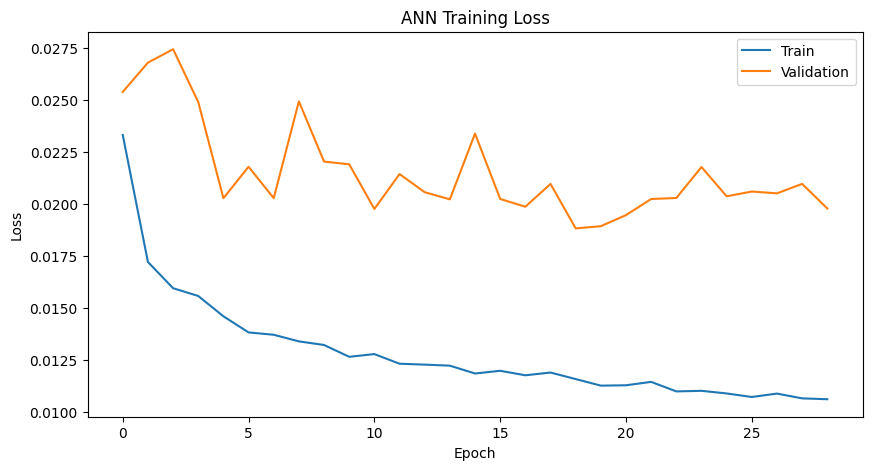

In [7]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("ANN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()


In [8]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = math.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("RMSE:", rmse)

print("R2 :", r2)

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE : 0.09006819015783213
RMSE: 0.13956180323503506
R2 : 0.7680747343186486


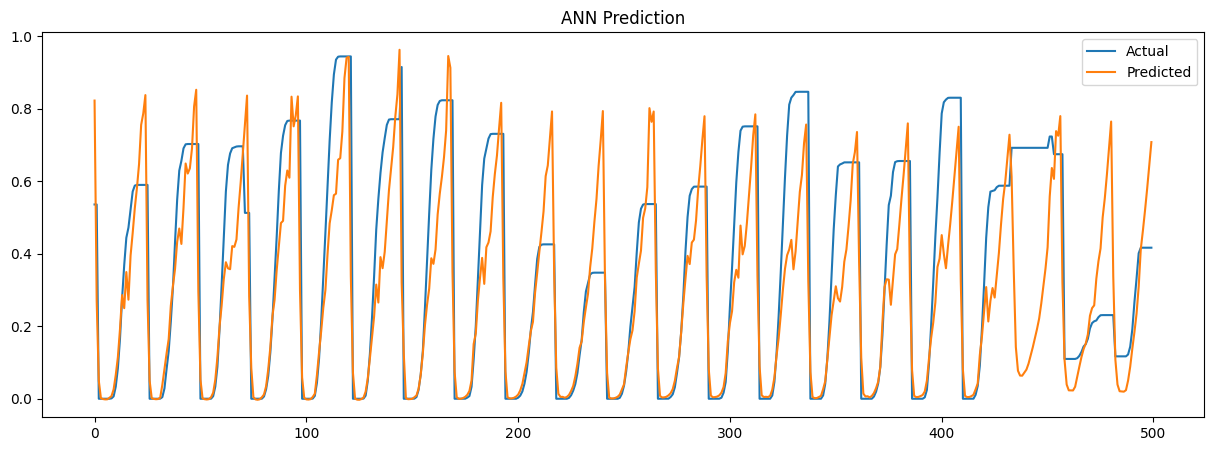

In [23]:
plt.figure(figsize=(15,5))

plt.plot(y_test[:500], label='Actual')

plt.plot(y_pred[:500], label='Predicted')

plt.legend()

plt.title("ANN Prediction")

plt.show()